<a href="https://colab.research.google.com/github/philk30/ClearSync_API/blob/main/MIMIC_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
#Importing Packages
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#authenticating with Google BigQuery Project to pull in MIMIC-IV dataset
auth.authenticate_user()
print('Authenticated successfully')

# Define your GCP Project ID
PROJECT_ID = "caresync-499601"


Authenticated successfully


In [11]:
from google.cloud import bigquery

# Initialize the client
client = bigquery.Client(project=PROJECT_ID)

# Define query with a python variable
query = f"""
    SELECT COUNT(DISTINCT subject_id) AS unique_count
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
"""

# Execute and convert directly to a DataFrame
number_of_patients = client.query(query).to_dataframe()
print(number_of_patients)


   unique_count
0        223452


In [21]:
print("Number of Patients in dataset = ", number_of_patients['unique_count'][0])

Number of Patients in dataset =  223452


In [4]:
query = f"""SELECT * FROM `physionet-data.mimiciv_3_1_hosp.admissions` """

# Initialize the client
client = bigquery.Client(project=PROJECT_ID)
admissions_df = number_of_patients = client.query(query).to_dataframe()


### Patient Demographics

In [17]:
#Number of patients in the dataset
number_of_patients = admissions_df['subject_id'].nunique()
print("Number of Patients in dataset = ", number_of_patients, "patients")

Number of Patients in dataset =  223452 patients


In [18]:
number_of_hospitalizations = len(admissions_df['subject_id'])
print("Number of hospitalizations in dataset = ", number_of_hospitalizations, "hospitalizations")

Number of hospitalizations in dataset =  546028 hospitalizations


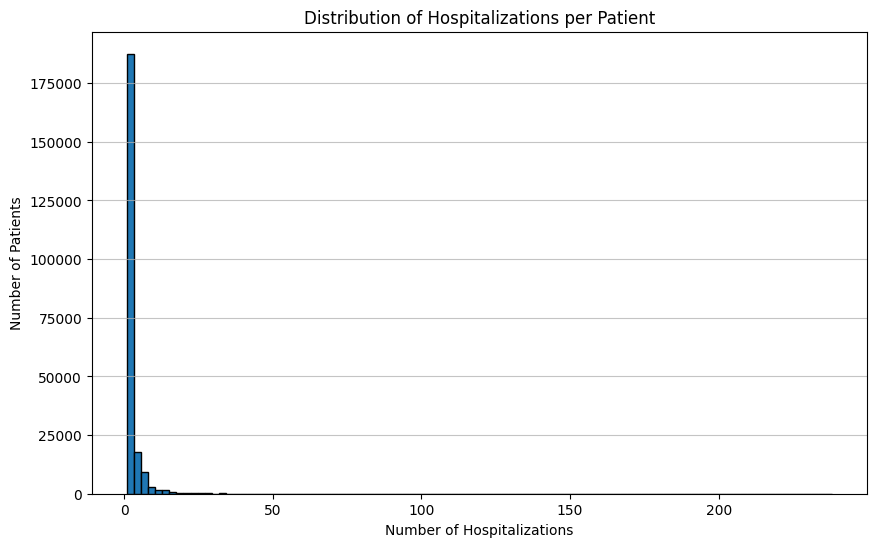

In [58]:
subject_id_counts = admissions_df['subject_id'].value_counts()

plt.figure(figsize=(10, 6))
subject_id_counts.plot.hist(bins=100, edgecolor='black')
plt.title('Distribution of Hospitalizations per Patient')
plt.xlabel('Number of Hospitalizations')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Languages spoken by patients
- The patients in the dataset speak 25 different languages with English being the majority at above 85%.

In [94]:
language_spoken = admissions_df.drop_duplicates(subset=['subject_id'])['language'].value_counts()
language_spoken

,count
language,
English,202713
Spanish,6783
Chinese,3369
Russian,2415
Kabuverdianu,1750
Portuguese,1452
Haitian,1003
Other,608
Vietnamese,494


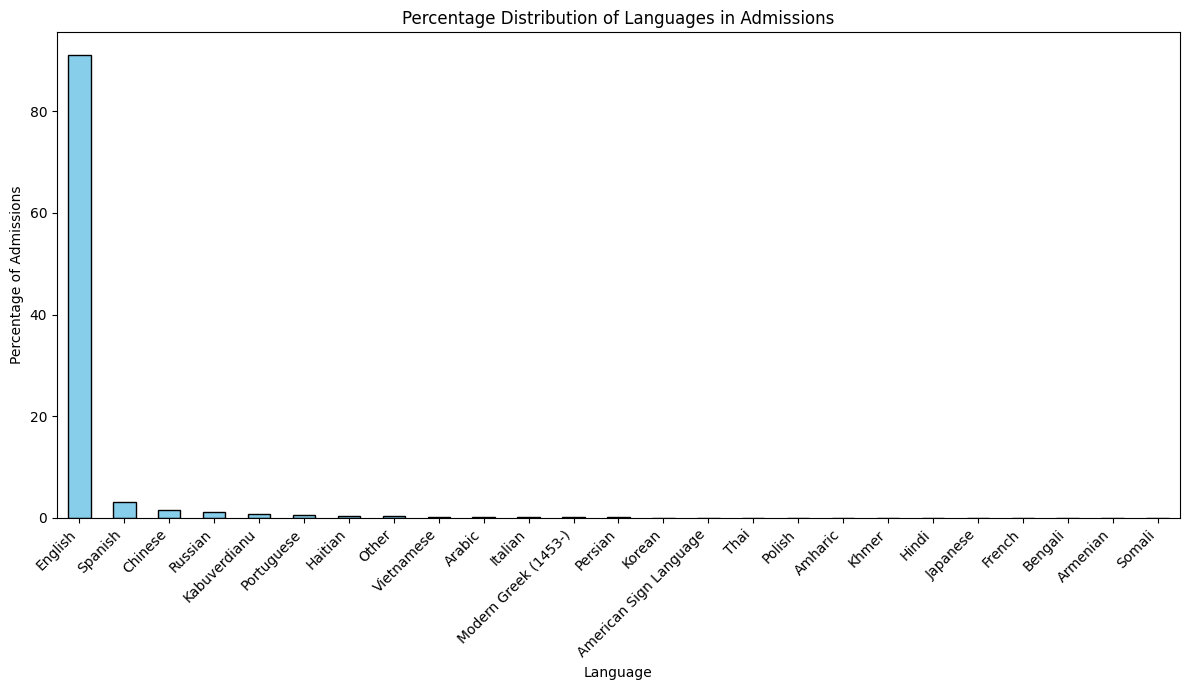

In [91]:
language_counts = admissions_df.drop_duplicates(subset=['subject_id'])['language'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 7))
language_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Percentage Distribution of Languages in Admissions')
plt.xlabel('Language')
plt.ylabel('Percentage of Patients')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Length of a hospital stay

- Below we calculate the length of stay per admissions. Showing the mean, standard deviation, median, and maximum stay.
- The average for each LOS is 4 days, with the maximum of 515 days.
- The minimum LOS of is -1 days indicating possible data entry errors with the discharge date/time

In [67]:
LOS_per_admissions = admissions_df['dischtime'] - admissions_df['admittime']


In [69]:
LOS_per_admissions.describe()


,0
count,546028
mean,4 days 18:16:54.480283
std,7 days 04:58:15.641908
min,-1 days +01:19:00
25%,1 days 03:05:00
50%,2 days 19:38:00
75%,5 days 14:55:00
max,515 days 13:30:00


In [73]:
admissions_df[LOS_per_admissions < pd.Timedelta(0)][['admittime', 'dischtime', 'edregtime', 'edouttime']]

,admittime,dischtime,edregtime,edouttime
7248,2193-02-16 22:20:00,2193-02-16 00:01:00,2193-02-16 19:45:00,2193-02-16 23:19:00
7592,2119-03-02 11:03:00,2119-03-02 00:01:00,NaT,NaT
27396,2141-03-25 07:02:00,2141-03-25 06:59:00,2141-03-25 04:40:00,2141-03-25 06:59:00
30073,2139-08-05 08:35:00,2139-08-05 00:00:00,2139-08-05 06:44:00,2139-08-05 09:40:00
30135,2184-12-21 10:57:00,2184-12-21 08:00:00,NaT,NaT
...,...,...,...,...
536499,2164-10-17 15:08:00,2164-10-17 00:01:00,2164-10-17 13:18:00,2164-10-17 17:25:00
536810,2110-02-14 02:13:00,2110-02-14 00:00:00,2110-02-14 00:55:00,2110-02-14 03:47:00
541721,2189-01-30 14:16:00,2189-01-30 00:30:00,2189-01-30 12:23:00,2189-01-30 15:41:00
544125,2172-05-27 20:13:00,2172-05-27 20:05:00,2172-05-27 14:59:00,2172-05-27 20:05:00


In [95]:
# Sort the DataFrame by subject_id and admittime to ensure correct chronological order
admissions_df_sorted = admissions_df.sort_values(by=['subject_id', 'admittime'])

# Calculate the time difference between the current admission's admittime and the previous admission's dischtime
admissions_df_sorted['previous_dischtime'] = admissions_df_sorted.groupby('subject_id')['dischtime'].shift(1)
admissions_df_sorted['time_since_last_discharge'] = admissions_df_sorted['admittime'] - admissions_df_sorted['previous_dischtime']

# Define the 30-day readmission threshold
readmission_threshold = pd.Timedelta(days=30)

# Create a boolean column to identify readmissions after more than 30 days
admissions_df_sorted['is_readmitted_after_30_days'] = admissions_df_sorted['time_since_last_discharge'] > readmission_threshold

# Optionally, create a DataFrame of only the readmitted patients
readmitted_patients_df = admissions_df_sorted[admissions_df_sorted['is_readmitted_after_30_days']].copy()

print("Admissions DataFrame with readmission column added (first 5 rows with readmissions > 30 days):")
display(admissions_df_sorted[admissions_df_sorted['is_readmitted_after_30_days']].head())

print("\nNumber of admissions identified as readmissions after > 30 days:")
print(readmitted_patients_df.shape[0])

print("\nNumber of unique patients identified as readmitted after > 30 days:")
print(readmitted_patients_df['subject_id'].nunique())

Admissions DataFrame with readmission column added (first 5 rows with readmissions > 30 days):


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,previous_dischtime,time_since_last_discharge,is_readmitted_after_30_days
431878,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0,2180-05-07 17:15:00,50 days 01:12:00,True
203880,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,NaT,EU OBSERVATION,P35NE4,PHYSICIAN REFERRAL,None,Medicare,English,MARRIED,WHITE,2160-12-27 18:32:00,2160-12-28 16:07:00,0,2160-11-25 14:52:00,32 days 14:19:00,True
77571,10000117,27988844,2183-09-18 18:10:00,2183-09-21 16:30:00,NaT,OBSERVATION ADMIT,P13ACE,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,Medicaid,English,DIVORCED,WHITE,2183-09-18 08:41:00,2183-09-18 20:20:00,0,2181-11-15 14:52:00,672 days 03:18:00,True
305681,10000635,20642640,2143-12-23 14:55:00,2143-12-24 12:52:00,NaT,EU OBSERVATION,P553YZ,WALK-IN/SELF REFERRAL,None,Medicare,English,WIDOWED,BLACK/AFRICAN AMERICAN,2143-12-23 07:43:00,2143-12-24 12:52:00,0,2136-06-20 11:30:00,2742 days 03:25:00,True
512291,10000690,23280645,2150-09-16 19:48:00,2150-09-24 13:50:00,NaT,EW EMER.,P941QM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE,2150-09-16 16:00:00,2150-09-16 21:03:00,0,2150-07-07 15:42:00,71 days 04:06:00,True



Number of admissions identified as readmissions after > 30 days:
213183

Number of unique patients identified as readmitted after > 30 days:
83438


In [107]:
plt.figure(figsize=(12, 7))

t=readmitted_patients_df['subject_id'].value_counts#(normalize=True) * 100
t.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Percentage Distribution of Readmissions per Patient')
plt.xlabel('Number of Readmissions')
plt.ylabel('Percentage of Patients')

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7fd2cb78b100> (for post_execute):


KeyboardInterrupt: 

In [100]:
readmitted_patients_df['subject_id'].value_counts()

,count
subject_id,
18284271,56
11582633,51
13475033,48
12251785,45
11965254,44
...,...
19996061,1
19995832,1
19995790,1
